### 节点并行执行

在 LangGraph 中，**并行（fan-out / fan-in）** 指：一个节点同时连向多个下游节点，
这些下游节点在同一个 **superstep（超步）** 内并发执行，等它们全部结束后再汇入公共下游节点。

```
        ┌──▶ fetch_a ──┐
START ──┤              ├──▶ merge ──▶ END
        └──▶ fetch_b ──┘
```

本节状态使用 **Pydantic `BaseModel`** 定义：
既能给字段默认值、拥有属性访问，又能在更新时做运行时校验。

并行能显著缩短耗时，但也带来几类典型异常：

| 异常场景 | 现象 | 处理方法 |
| --- | --- | --- |
| 多个分支写同一个 state key，但该 key 没有 reducer | `InvalidUpdateError` | 用 `Annotated[key, reducer]` |
| 分支完成顺序不确定 | 合并结果顺序不稳定 | 用顺序无关 reducer / join 内显式排序 |
| 某个分支抛异常 | 整张图失败，已成功的分支结果作废 | `retry_policy` / 节点内 `try-except` / `Command` 路由 |
| 重试耗尽仍失败 | 抛出原始异常 | 控制 `max_attempts`、保证幂等、错误处理节点 |
| 原地修改 state | 修改被静默丢弃 / 与返回值混用出错 | 只通过返回值更新 |

下面逐条用可运行代码演示。

### 0. 公共导入与状态定义（Pydantic）

In [1]:
from typing import Annotated
from operator import add
import time

from pydantic import BaseModel, Field

from IPython.display import Image, display
from langgraph.errors import InvalidUpdateError
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy, Command


def show(graph):
    # 渲染图结构；离线时退化为打印 mermaid 文本
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("跳过图形渲染：", e)
        print(graph.get_graph().draw_mermaid())


class ParallelState(BaseModel):
    # 并行分支各自追加 -> 用 add 做 reducer；默认空列表
    logs: Annotated[list[str], add] = Field(default_factory=list)
    # 故意不带 reducer，用于演示并发写冲突
    count: int
    # 可选字段：错误信息
    error: str | None = None

### 基础：正确的并行 fan-out / fan-in

`fetch_a`、`fetch_b` 同时执行，结果通过 `logs` 的 `add` reducer 合并，最后汇聚到 `merge`。
节点里用属性访问（`state.logs`），返回 `dict` 作为增量更新。

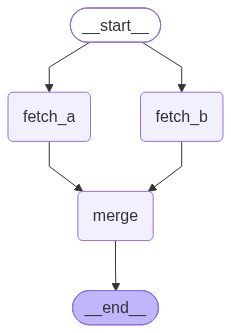

{'logs': ['fetch_a 完成', 'fetch_b 完成', 'merge 收到 2 条日志'], 'count': 2}
总耗时 0.21s（≈max(0.20, 0.05)，说明是并行执行）


In [2]:
def fetch_a(state: ParallelState) -> dict:
    time.sleep(0.20)                       # 模拟慢请求
    return {"logs": ["fetch_a 完成"]}


def fetch_b(state: ParallelState) -> dict:
    time.sleep(0.05)                       # 模拟快请求
    return {"logs": ["fetch_b 完成"]}


def merge(state: ParallelState) -> dict:
    return {"logs": [f"merge 收到 {len(state.logs)} 条日志"]}   # 属性访问


builder = StateGraph(ParallelState)
builder.add_node("fetch_a", fetch_a)
builder.add_node("fetch_b", fetch_b)
builder.add_node("merge", merge)
builder.add_edge(START, "fetch_a")         # fan-out：起点同时连两个节点
builder.add_edge(START, "fetch_b")
builder.add_edge("fetch_a", "merge")       # fan-in：两个节点都汇入 merge
builder.add_edge("fetch_b", "merge")
builder.add_edge("merge", END)

app = builder.compile()
show(app)

start = time.time()
result = app.invoke({"count": 2})          # logs/error 有默认值，无需传入
print(result)
print(f"总耗时 {time.time() - start:.2f}s（≈max(0.20, 0.05)，说明是并行执行）")

### 异常场景 1：并行写同一个 key，但该 key 没有 reducer

两个并行分支在**同一步**都返回 `count`，而 `count` 没有声明 reducer，
LangGraph 不知道该保留哪个值，于是抛出 `InvalidUpdateError`。

In [3]:
def bad_a(state: ParallelState) -> dict:
    return {"count": 1}


def bad_b(state: ParallelState) -> dict:
    return {"count": 2}


bad_builder = StateGraph(ParallelState)
bad_builder.add_node("bad_a", bad_a)
bad_builder.add_node("bad_b", bad_b)
bad_builder.add_edge(START, "bad_a")
bad_builder.add_edge(START, "bad_b")
bad_builder.add_edge("bad_a", END)
bad_builder.add_edge("bad_b", END)

try:
    bad_builder.compile().invoke({"count": 0})
except InvalidUpdateError as e:
    print("捕获到 InvalidUpdateError：")
    print(e)

捕获到 InvalidUpdateError：
At key 'count': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


### 处理方法 1：给 key 声明 reducer

用 `Annotated[类型, 归约函数]` 告诉 LangGraph 如何合并并发更新：

- `Annotated[list, add]`：列表追加；
- `Annotated[int, add]`：数值求和；
- 自定义函数：例如「后写覆盖」「取最大」「去重」等。

reducer 的签名是 `(旧值, 新值) -> 合并后的值`，必须返回结果。

In [4]:
class SumState(BaseModel):
    logs: Annotated[list[str], add] = Field(default_factory=list)
    total: Annotated[int, add] = 0     # 并发写同一个 int：用 add 求和


def sum_a(state: SumState) -> dict:
    return {"logs": ["a"], "total": 1}


def sum_b(state: SumState) -> dict:
    return {"logs": ["b"], "total": 2}


sum_builder = StateGraph(SumState)
sum_builder.add_node("a", sum_a)
sum_builder.add_node("b", sum_b)
sum_builder.add_edge(START, "a")
sum_builder.add_edge(START, "b")
sum_builder.add_edge("a", END)
sum_builder.add_edge("b", END)

print(sum_builder.compile().invoke({}))

{'logs': ['a', 'b'], 'total': 3}


### 异常场景 2：并行分支的完成顺序不确定

并行分支谁先完成由调度和耗时决定，**reducer 的合并顺序 = 完成顺序**，
所以带 reducer 的列表顺序不稳定。下面给两个分支不同延时即可看到。

In [5]:
class OrderState(BaseModel):
    logs: Annotated[list[str], add] = Field(default_factory=list)
    ordered: list[str] = Field(default_factory=list)   # 只有 join 写，无并发，安全


def make_worker(name: str, delay: float):
    def worker(state: OrderState) -> dict:
        time.sleep(delay)
        return {"logs": [name]}
    return worker


order_builder = StateGraph(OrderState)
order_builder.add_node("slow", make_worker("slow", 0.30))
order_builder.add_node("fast", make_worker("fast", 0.05))
order_builder.add_edge(START, "slow")
order_builder.add_edge(START, "fast")
order_builder.add_edge("slow", END)
order_builder.add_edge("fast", END)

order_app = order_builder.compile()
for i in range(3):
    print(f"第 {i + 1} 次:", order_app.invoke({})["logs"])

第 1 次: ['fast', 'slow']
第 2 次: ['fast', 'slow']
第 3 次: ['fast', 'slow']


### 处理方法 2：不要依赖合并顺序

- 让 reducer 与顺序无关（求和、取并集、按 key 覆盖等）；
- 需要稳定顺序时，先把结果收集齐，再在 join 节点里**显式排序 / 编号**；
- 给结果带上来源标识，join 时按来源取用。

In [7]:
def merge_sorted(state: OrderState) -> dict:
    # join 在并行分支全部结束后才执行，此时 logs 已收集完整
    return {"ordered": sorted(state.logs, reverse=True)}


sorted_builder = StateGraph(OrderState)
sorted_builder.add_node("slow", make_worker("slow", 0.20))
sorted_builder.add_node("fast", make_worker("fast", 0.05))
sorted_builder.add_node("join", merge_sorted)
sorted_builder.add_edge(START, "slow")
sorted_builder.add_edge(START, "fast")
sorted_builder.add_edge("slow", "join")
sorted_builder.add_edge("fast", "join")
sorted_builder.add_edge("join", END)

res = sorted_builder.compile().invoke({})
print("原始合并:", res["logs"])
print("排序结果:", res["ordered"])

原始合并: ['fast', 'slow']
排序结果: ['slow', 'fast']


### 异常场景 3：某个并行分支抛异常，整张图失败

并行分支中任意一个抛出未捕获异常，都会让整次 `invoke` 失败；
**其他分支即使已经执行成功，结果也会作废**。

In [8]:
class FailState(BaseModel):
    logs: Annotated[list[str], add] = Field(default_factory=list)


def good_node(state: FailState) -> dict:
    print("  good 分支执行了")
    return {"logs": ["good"]}


def bad_node(state: FailState) -> dict:
    print("  bad 分支执行了")
    raise RuntimeError("bad 分支调用外部接口失败")


fail_builder = StateGraph(FailState)
fail_builder.add_node("good", good_node)
fail_builder.add_node("bad", bad_node)
fail_builder.add_edge(START, "good")
fail_builder.add_edge(START, "bad")
fail_builder.add_edge("good", END)
fail_builder.add_edge("bad", END)

try:
    fail_builder.compile().invoke({})
except RuntimeError as e:
    print("整图失败：", e)

  bad 分支执行了
  good 分支执行了
整图失败： bad 分支调用外部接口失败


### 处理方法 3a：为节点配置重试策略 `RetryPolicy`

给容易抖动的节点（网络请求、外部 API）加 `retry_policy`，失败后自动重试；
只有超过 `max_attempts` 才真正抛出。可用 `retry_on` 指定只对某些异常重试。

In [9]:
attempts = {"flaky": 0}


def flaky_node(state: FailState) -> dict:
    attempts["flaky"] += 1
    print(f"  flaky 第 {attempts['flaky']} 次尝试")
    if attempts["flaky"] < 3:
        raise ValueError("偶发失败")
    return {"logs": ["flaky 最终成功"]}


retry_builder = StateGraph(FailState)
retry_builder.add_node(
    "flaky",
    flaky_node,
    retry_policy=RetryPolicy(max_attempts=5, retry_on=ValueError),
)
retry_builder.add_edge(START, "flaky")
retry_builder.add_edge("flaky", END)

print(retry_builder.compile().invoke({}))
print("总尝试次数:", attempts["flaky"])

  flaky 第 1 次尝试
  flaky 第 2 次尝试
  flaky 第 3 次尝试
{'logs': ['flaky 最终成功']}
总尝试次数: 3


### 处理方法 3b：节点内 `try / except`，返回兜底状态

对「失败可降级」的分支，在节点内部捕获异常并返回兜底值，让整张图继续往下走。

In [10]:
class SafeState(BaseModel):
    logs: Annotated[list[str], add] = Field(default_factory=list)
    error: str | None = None


def safe_node(state: SafeState) -> dict:
    try:
        raise ConnectionError("下游服务不可用")
    except Exception as e:
        # 不向上抛，改为返回降级结果 + 错误信息
        return {"logs": ["safe_node 降级返回"], "error": str(e)}


safe_builder = StateGraph(SafeState)
safe_builder.add_node("safe", safe_node)
safe_builder.add_edge(START, "safe")
safe_builder.add_edge("safe", END)

print("降级结果:", safe_builder.compile().invoke({}))

降级结果: {'logs': ['safe_node 降级返回'], 'error': '下游服务不可用'}


### 处理方法 3c：用 `Command` 路由到专门的错误处理节点

捕获异常后返回 `Command(goto="错误处理节点", update={...})`，
把流程显式导向专门的错误处理分支，而不是直接失败。

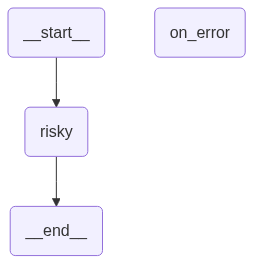

{'logs': ['risky 捕获异常', '错误处理节点收到: 调用超时'], 'error': '调用超时'}


In [11]:
def risky_node(state: SafeState):
    try:
        raise TimeoutError("调用超时")
    except Exception as e:
        # 记录错误并跳转到 on_error 节点
        return Command(
            goto="on_error",
            update={"logs": ["risky 捕获异常"], "error": str(e)},
        )


def on_error(state: SafeState) -> dict:
    return {"logs": [f"错误处理节点收到: {state.error}"]}   # 属性访问


command_builder = StateGraph(SafeState)
command_builder.add_node("risky", risky_node)
command_builder.add_node("on_error", on_error)
command_builder.add_edge(START, "risky")
command_builder.add_edge("risky",END)
# risky 通过 Command.goto 跳转
command_builder.add_edge("on_error", END)
graph = command_builder.compile()
show(graph)
print(graph.invoke({}))

### 异常场景 4：重试耗尽仍然失败

`retry_policy` 不是万能：若异常持续发生，超过 `max_attempts` 后仍会向上抛出，整图失败。
所以重试只适合**偶发**故障，且节点应保证**幂等**（重复执行不产生副作用）。

In [12]:
def permanent_fail(state: FailState) -> dict:
    raise RuntimeError("永久性故障，重试无用")


exhaust_builder = StateGraph(FailState)
exhaust_builder.add_node(
    "x", permanent_fail, retry_policy=RetryPolicy(max_attempts=3)
)
exhaust_builder.add_edge(START, "x")
exhaust_builder.add_edge("x", END)

try:
    exhaust_builder.compile().invoke({})
except RuntimeError as e:
    print("重试耗尽后仍抛出：", e)

重试耗尽后仍抛出： 永久性故障，重试无用


### 异常场景 5：依赖原地修改 state（反例）

在节点里直接写 `state.logs.append(...)` 修改原对象，**不要指望它生效**：
用 Pydantic 作为状态时，节点拿到的是经过校验的模型，原地修改会被**静默丢弃**；
即使某些配置下能生效，也破坏了「节点只返回增量」的约定，和 reducer 一起用时还可能产生重复数据。

**处理原则：只通过返回值更新状态，不要在节点里原地修改 state。**

In [13]:
class MutateState(BaseModel):
    logs: Annotated[list[str], add] = Field(default_factory=list)


def mutate_and_return(state: MutateState) -> dict:
    state.logs.append("原地追加")        # 反例：直接修改原对象（会被丢弃）
    return {"logs": ["返回值追加"]}       # 只有返回值会被合并进新状态


mutate_builder = StateGraph(MutateState)
mutate_builder.add_node("m", mutate_and_return)
mutate_builder.add_edge(START, "m")
mutate_builder.add_edge("m", END)

print("结果:", mutate_builder.compile().invoke({})["logs"])
print("可以看到「原地追加」丢失了，只有返回值生效")

结果: ['返回值追加']
可以看到「原地追加」丢失了，只有返回值生效


### 小结：并行执行的异常与处理

| 异常场景 | 根因 | 处理方式 |
| --- | --- | --- |
| `InvalidUpdateError` | 多个并行分支写同一个未声明 reducer 的 key | 加 `Annotated[key, reducer]` |
| 合并顺序不稳定 | 分支完成顺序不确定 | 顺序无关 reducer；join 内显式排序 |
| 分支异常导致整图失败 | 未捕获异常向上传播 | `retry_policy` / `try-except` 降级 / `Command` 路由 |
| 重试耗尽仍失败 | 持续性故障 | 限制 `max_attempts`、保证幂等、错误处理节点 |
| 原地修改 state | Pydantic 校验会丢弃原地修改 | 只通过返回值更新状态 |

**实践建议**

1. 并行分支要写的 key，先想清楚 reducer 语义。
2. reducer 尽量满足「顺序无关」，不要依赖完成顺序。
3. 外部调用节点加 `retry_policy`，并保证节点幂等。
4. 可降级的分支用 `try / except` 兜底；需要走专门流程用 `Command`。
5. 永远不要在节点里原地修改 state，只返回增量。